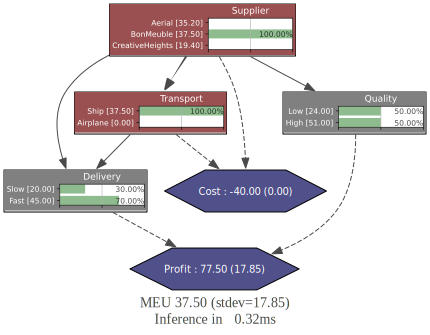

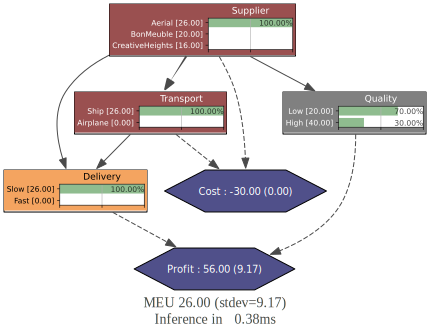

In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb

idg = gum.InfluenceDiagram()

transport = idg.addDecisionNode(gum.LabelizedVariable("Transport", "Transport Mode", ["Ship", "Airplane"]))
supply = idg.addDecisionNode(gum.LabelizedVariable("Supplier", "Supplier Choice", ["Aerial", "BonMeuble", "CreativeHeights"]))
quality = idg.addChanceNode(gum.LabelizedVariable("Quality", "Desk Quality", ["Low", "High"]))
delivery = idg.addChanceNode(gum.LabelizedVariable("Delivery", "Delivery Time", ["Slow", "Fast"]))

#utility = idg.addUtilityNode(gum.LabelizedVariable("Utility", "Profit per desk", 1))
cost = idg.addUtilityNode(gum.LabelizedVariable("Cost", "Cost", 1))
profit = idg.addUtilityNode(gum.LabelizedVariable("Profit", "Profit", 1))

idg.addArc(supply, transport)
idg.addArc(supply, quality)
idg.addArc(supply, delivery)
idg.addArc(supply, cost)
idg.addArc(transport, delivery)
idg.addArc(transport, cost)
idg.addArc(delivery, profit)
idg.addArc(quality, profit)

idg.cpt(delivery)[{"Supplier": "Aerial", "Transport": "Ship"}] = [0.6, 0.4]
idg.cpt(delivery)[{"Supplier": "BonMeuble", "Transport": "Ship"}] = [0.3, 0.7]
idg.cpt(delivery)[{"Supplier": "CreativeHeights", "Transport": "Ship"}] = [0.9, 0.1]
idg.cpt(delivery)[{"Supplier": "Aerial", "Transport": "Airplane"}] = [0.8, 0.2]
idg.cpt(delivery)[{"Supplier": "BonMeuble", "Transport": "Airplane"}] = [0.1, 0.9]
idg.cpt(delivery)[{"Supplier": "CreativeHeights", "Transport": "Airplane"}] = [0.7, 0.3]

idg.cpt(quality)[{"Supplier": "Aerial"}] = [0.7, 0.3]
idg.cpt(quality)[{"Supplier": "BonMeuble"}] = [0.5, 0.5]
idg.cpt(quality)[{"Supplier": "CreativeHeights"}] = [0.2, 0.8]
idg.utility(profit)[{'Delivery': 'Slow', 'Quality': 'Low'}] = 50
idg.utility(profit)[{'Delivery': 'Slow', 'Quality': 'High'}] = 70
idg.utility(profit)[{'Delivery': 'Fast', 'Quality': 'Low'}] = 70
idg.utility(profit)[{'Delivery': 'Fast', 'Quality': 'High'}] = 100

idg.utility(cost)[{'Supplier': 'Aerial', 'Transport': 'Ship'}] = -20 -10
idg.utility(cost)[{'Supplier': 'Aerial', 'Transport': 'Airplane'}] = -20 - 15
idg.utility(cost)[{'Supplier': 'CreativeHeights', 'Transport': 'Ship'}] = -40 - 10
idg.utility(cost)[{'Supplier': 'CreativeHeights', 'Transport': 'Airplane'}] = -40 - 15
idg.utility(cost)[{'Supplier': 'BonMeuble', 'Transport': 'Ship'}] = -30 -10
idg.utility(cost)[{'Supplier': 'BonMeuble', 'Transport': 'Airplane'}] = -30 - 15

#def get_profit(params):
    #prices = {
        #('Slow', 'Low'): 50,
        #('Fast', 'Low'): 70,
        #('Slow', 'High'): 70,
        #('Fast', 'High'): 100}

    #s_costs = {'Aerial': 20, 'BonMeuble': 30, 'CreativeHeights': 40}
    #t_costs = {'Ship': 10, 'Airplane': 15}

    #rev = prices[(params["Delivery"], params["Quality"])]
    #cost = s_costs[params["Supplier"]] + t_costs[params["Transport"]]
    #return rev - cost

gnb.showInference(idg)
gnb.sideBySide(idg.cpt(delivery), idg.cpt(quality))
gnb.sideBySide(idg.utility(cost), idg.utility(profit))
gnb.showInference(idg, evs={"Delivery": "Slow"})